<center><img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  /></center>
  


## Lab: Advanced Data Augmentation with Keras 


##### Estimated time needed:  30 minutes


You will learn to implement and experiment with various data augmentation techniques using Keras in this lab. 

#### Learning objectives 

By the end of this lab, you will: 

- Implement various data augmentation techniques using Keras 
- Implement feature-wise and sample-wise normalization on the data set. 
- Define and apply a custom augmentation function that adds random noise to images. 
- Display the augmented images to understand the effect of different augmentation techniques.  


#### Step-by-step instructions 

##### Step 1: Setup the environment 

First, you need to import the necessary libraries and load the data set as follows: 


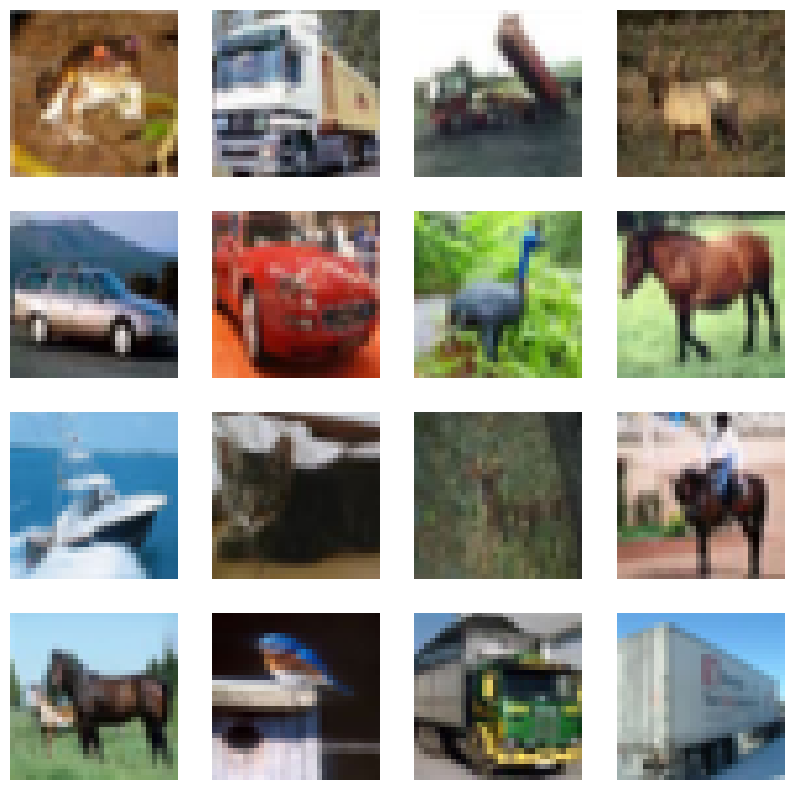

In [1]:
# Install required libraries
#!pip install tensorflow==2.16.2 matplotlib==3.9.1 scipy

# Import necessary libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load CIFAR-10 dataset for training images
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize the pixel values for augmentation
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Display a sample of the training images
plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(x_train[i])
    plt.axis('off')
plt.show()


### **Create sample.jpg for the Lab**


In [2]:
from PIL import Image, ImageDraw

# Create a blank white image
image = Image.new('RGB', (224, 224), color = (255, 255, 255))

# Draw a red square
draw = ImageDraw.Draw(image)
draw.rectangle([(50, 50), (174, 174)], fill=(255, 0, 0))

# Save the image
image.save('sample.jpg')


In [3]:
import numpy as np 
import matplotlib.pyplot as plt 
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array 

# Load a sample image 
img_path = 'sample.jpg' 
img = load_img(img_path) 
x = img_to_array(img) 
x = np.expand_dims(x, axis=0) 

In the code: 
- `!pip install tensorflow==2.16.2 matplotlib==3.9.1` installs the specified versions of `TensorFlow and Matplotlib`.  

- `tensorflow` is the main library for machine learning in Python.  

- `Model` is used to create a model with the Functional API. 

- `Input` and ‘Dense’ are types of layers that you will use in your model.  


#### Step 2: Basic data augmentation 

Apply basic augmentations such as rotation, width shift, height shift, shear, zoom, and horizontal flip using the ImageDataGenerator as follows:


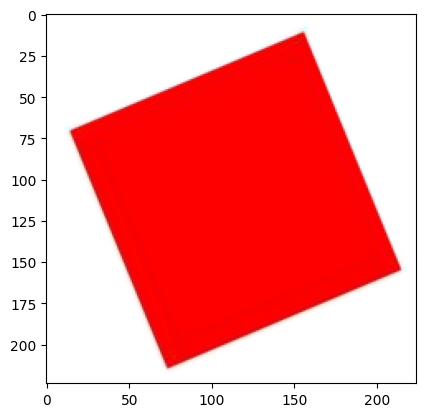

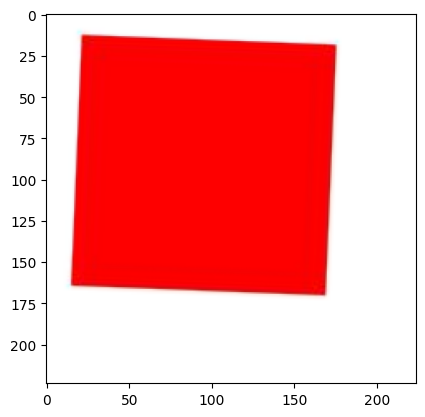

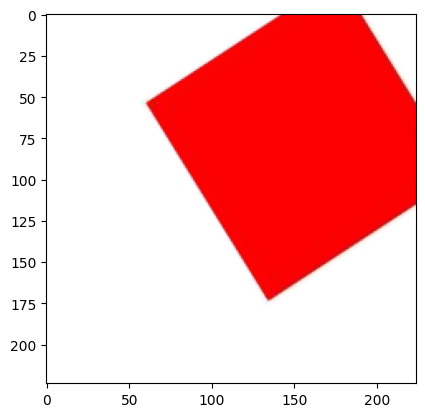

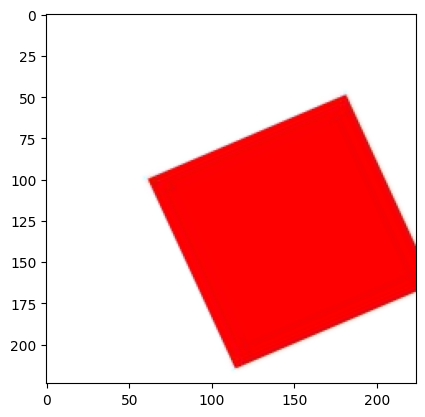

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

# Load the sample image
img_path = 'sample.jpg'
img = load_img(img_path)
x = img_to_array(img)
x = np.expand_dims(x, axis=0)

# Create an instance of ImageDataGenerator with basic augmentations
datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Generate batches of augmented images
i = 0
for batch in datagen.flow(x, batch_size=1):
    plt.figure(i)
    imgplot = plt.imshow(batch[0].astype('uint8'))
    i += 1
    if i % 4 == 0:
        break

plt.show()



#### Step 3: Feature-wise and sample-wise normalization 

Implement feature-wise and sample-wise normalization on the data set as follows:    


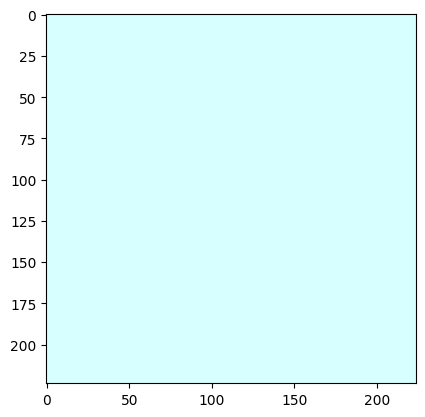

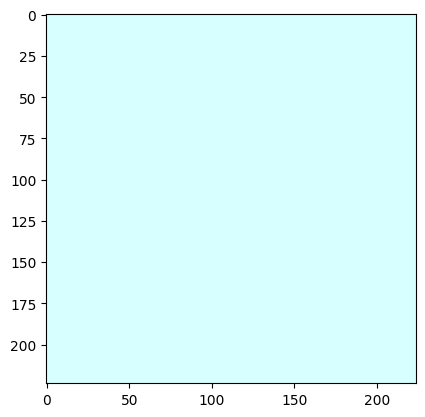

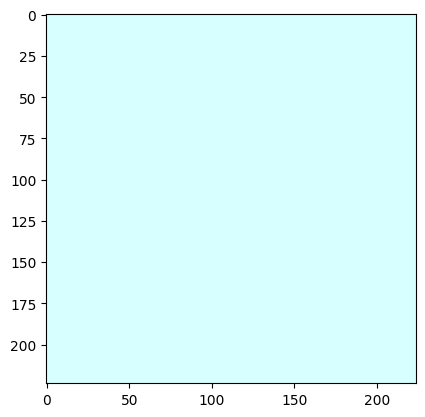

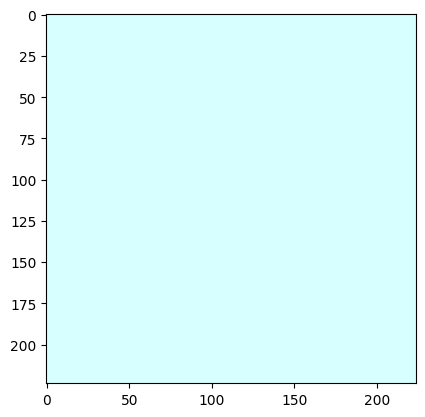

In [5]:
# Create an instance of ImageDataGenerator with normalization options
datagen = ImageDataGenerator(
    featurewise_center=True,
    featurewise_std_normalization=True,
    samplewise_center=True,
    samplewise_std_normalization=True
)

# Load the sample image again and fit the generator (normally done on the training set)
datagen.fit(x)

# Generate batches of normalized images
i = 0
for batch in datagen.flow(x, batch_size=1):
    plt.figure(i)
    imgplot = plt.imshow(batch[0].astype('uint8'))
    i += 1
    if i % 4 == 0:
        break

plt.show()




#### Step 4: Custom data augmentation function 

Next, you define and apply a custom augmentation function that adds random noise to images as follows: 


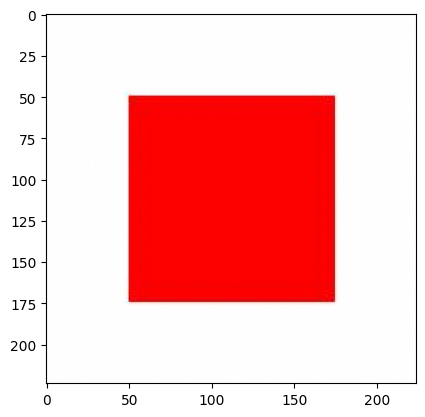

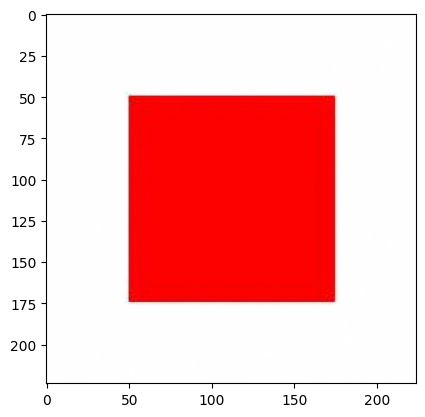

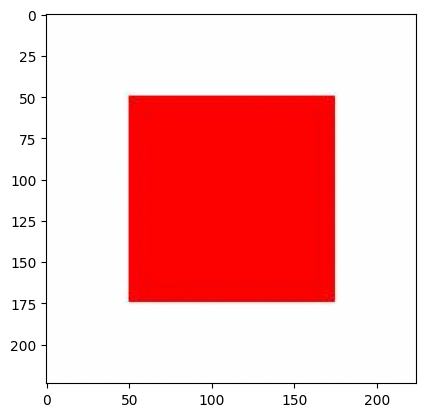

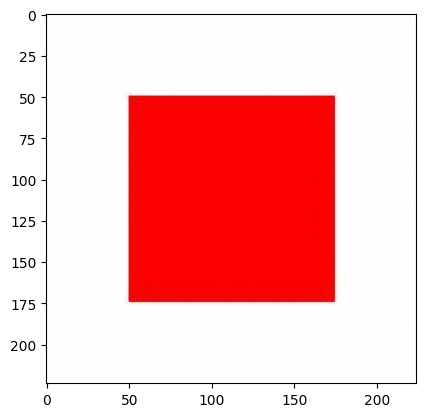

In [6]:
# Define a custom data augmentation function
def add_random_noise(image):
    noise = np.random.normal(0, 0.1, image.shape)
    return image + noise

# Create an instance of ImageDataGenerator with the custom augmentation
datagen = ImageDataGenerator(preprocessing_function=add_random_noise)

# Generate batches of augmented images with noise
i = 0
for batch in datagen.flow(x, batch_size=1):
    plt.figure(i)
    imgplot = plt.imshow(batch[0].astype('uint8'))
    i += 1
    if i % 4 == 0:
        break

plt.show()

#### Step 5: Visualize augmented images 

Visualize the augmented images to understand the impact of each augmentation technique. 


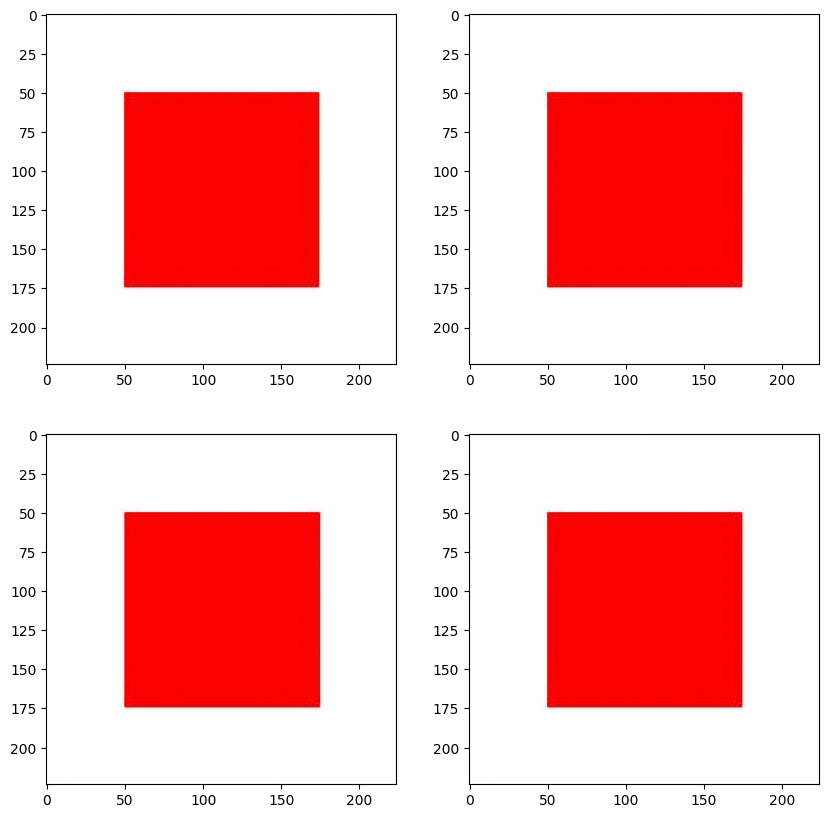

In [7]:
# Visualizing multiple augmented versions of the same image
plt.figure(figsize=(10, 10))
for i, batch in enumerate(datagen.flow(x, batch_size=1)):
    if i >= 4:  # Show only 4 versions
        break
    plt.subplot(2, 2, i+1)
    plt.imshow(batch[0].astype('uint8'))
plt.show()



This Markdown explanation will provide clarity in a Jupyter Notebook, making the code and its purpose easier to understand.


## Practice Exercises:


### Exercise 1: Apply and Visualize Different Augmentation Techniques 

  

Objective: Experiment with different augmentation techniques and visualize their effects. 


Download the `sample_images` folder containing a collection of images that will be used for this practice exercise.


In [11]:
# Download the sample images using Python urllib (Windows compatible)
import urllib.request
import os

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/RgP3JFNtPTZA34UmG3KZaA/sample-images.zip"
filename = "sample-images.zip"

print("Downloading sample-images.zip...")
urllib.request.urlretrieve(url, filename)
print("Download completed!")

Download completed!
Download completed!


Extract the images by unzipping the folder


In [12]:
# Extract the zip file using Python zipfile (Windows compatible)
import zipfile
import os

zip_filename = "sample-images.zip"
extract_folder = "."

print("Extracting sample-images.zip...")
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)
print("Extraction completed!")

# List the contents to verify extraction
if os.path.exists("sample_images"):
    print("Files extracted to 'sample_images' folder:")
    for file in os.listdir("sample_images"):
        print(f"  - {file}")
else:
    print("Checking extracted contents...")
    for item in os.listdir("."):
        if "image" in item.lower() or item.endswith(('.jpg', '.png')):
            print(f"  - {item}")

Extracting sample-images.zip...
Extraction completed!
Files extracted to 'sample_images' folder:
  - training_images1.jpg
  - training_images2.jpg
  - training_images3.jpg


### Instructions: 

1. Create an instance of `ImageDataGenerator` with various augmentations such as rotation, width shift, height shift, shear, zoom, and horizontal flip. 

2. Generate and visualize augmented images. 


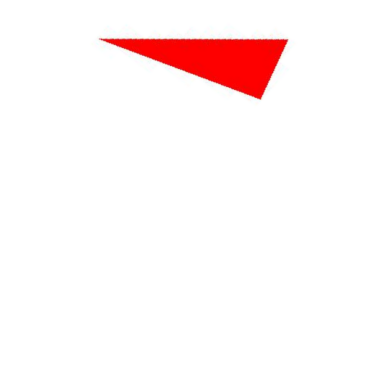

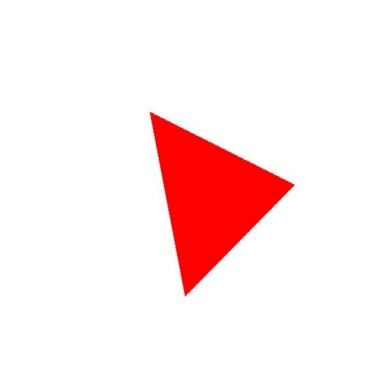

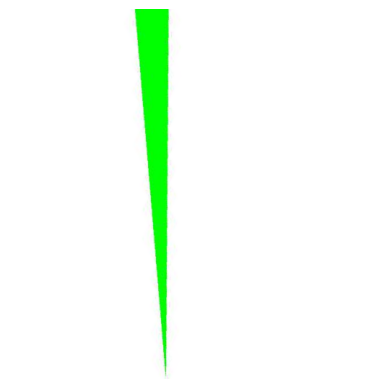

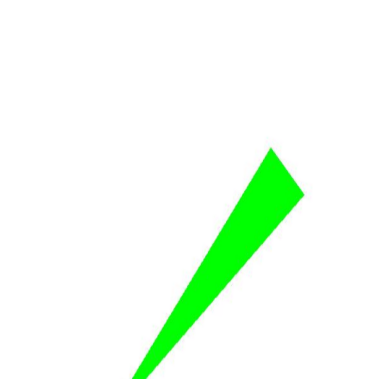

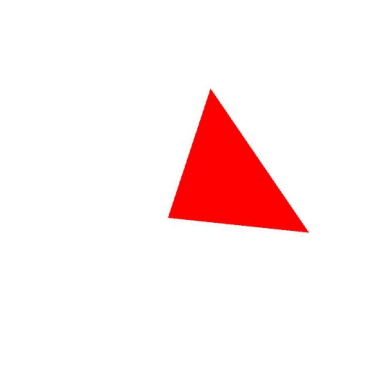

In [ ]:
datagenerator = ImageDataGenerator(
    rotation_range=50,
    width_shift_range=0.2,
    height_shift_range=0.3,
    shear_range=0.1,
    zoom_range=0.4,
    horizontal_flip=True,
    fill_mode='nearest'

)
x = load_img('sample_images/training_images1.jpg')
y = load_img('sample_images/training_images2.jpg')
z = load_img('sample_images/training_images3.jpg')
x = img_to_array(x)
y = img_to_array(y)
z = img_to_array(z)
x = np.expand_dims(x, axis=0)
y = np.expand_dims(y, axis=0)
z = np.expand_dims(z, axis=0)

images = np.vstack([x, y, z])


for i, image in enumerate(datagenerator.flow(images, batch_size=1)):
    plt.figure(i)
    plt.imshow(image[0].astype('uint8'))
    plt.axis('off')
    plt.show()
    if i >= 4:  
        break



<details>
    <summary>Click here for Solution</summary>

```python

 

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img  

import matplotlib.pyplot as plt  

import numpy as np  

 

# Define the augmentation parameters  

datagen = ImageDataGenerator(  

    rotation_range=40,  

    width_shift_range=0.2,  

    height_shift_range=0.2,  

    shear_range=0.2,  

    zoom_range=0.2,  

    horizontal_flip=True,  

    fill_mode='nearest'  

)  

 

# Load and preprocess the dataset  

image_paths = [  

    'sample_images/training_images1.jpg',  

    'sample_images/training_images2.jpg',  

    'sample_images/training_images3.jpg'  

]  

 

training_images = []  

for image_path in image_paths:  

    img = load_img(image_path, target_size=(224, 224))  

    img_array = img_to_array(img)  

    training_images.append(img_array)  

training_images = np.array(training_images)  

 

# Generate and visualize augmented images  

i = 0  

for batch in datagen.flow(training_images, batch_size=1):  

    plt.figure(i)  

    imgplot = plt.imshow(array_to_img(batch[0]))  

    plt.title(f'Augmented Image {i + 1}')  

    i += 1  

    if i % 4 == 0:  

        break  

plt.show()  

 ```   

</details>


### Exercise 2: Implement Feature-wise and Sample-wise Normalization
 
Objective: Apply feature-wise and sample-wise normalization to the dataset.
 
Instructions:
1. Create an instance of `ImageDataGenerator` with feature-wise and sample-wise normalization.
2. Fit the `ImageDataGenerator` to the data set and visualize the normalized images.


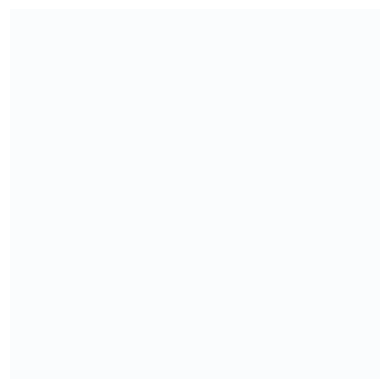

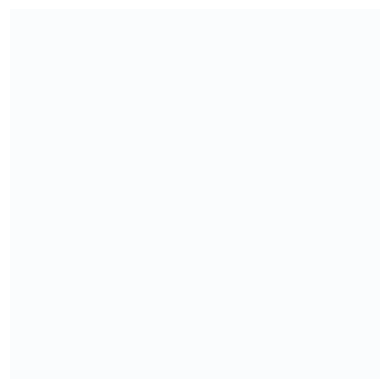

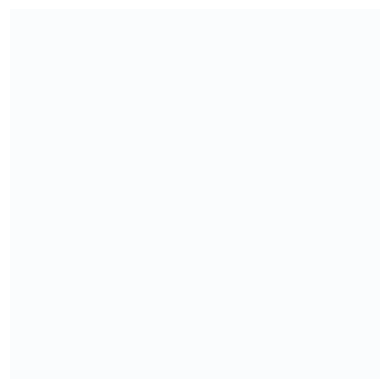

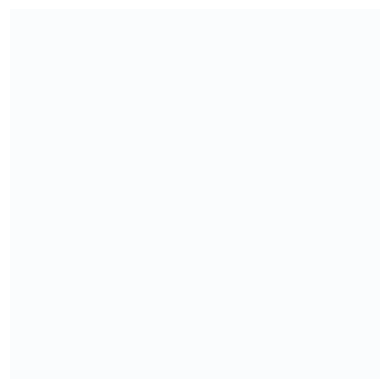

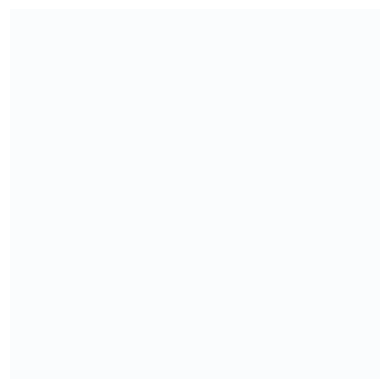

In [ ]:
datagenerator = ImageDataGenerator(
    featurewise_center=True,
    featurewise_std_normalization=True,
    samplewise_center=True,
    samplewise_std_normalization=True
)

datagenerator.fit(images)

for i, image in enumerate(datagenerator.flow(images, batch_size=1)):
    plt.figure(i)
    plt.imshow(image[0].astype('uint8'))
    plt.show()
    if i >= 4:  
        break


<details>
    <summary>Click here for Solution</summary>

```python
 

# Create an instance of ImageDataGenerator with normalization options  

datagen = ImageDataGenerator(  

    featurewise_center=True,  

    featurewise_std_normalization=True,  

    samplewise_center=True,  

    samplewise_std_normalization=True  

)  

 

# Fit the ImageDataGenerator to the dataset  

datagen.fit(training_images)  

 

# Generate and visualize normalized images  

i = 0  

for batch in datagen.flow(training_images, batch_size=1):  

    plt.figure(i)  

    imgplot = plt.imshow(array_to_img(batch[0]))  

    plt.title(f'Normalized Image {i + 1}')  

    i += 1  

    if i % 4 == 0:  

        break  

plt.show()  

 

 ```   

</details>

  


### Exercise 3: Create and Apply a Custom Data Augmentation Function
 
Objective: Define a custom data augmentation function that adds random noise to images and apply it.
 
Instructions:
1. Define a function that adds random noise to an image.
2. Create an instance of `ImageDataGenerator` with the custom augmentation function.
3. Generate and visualize augmented images.


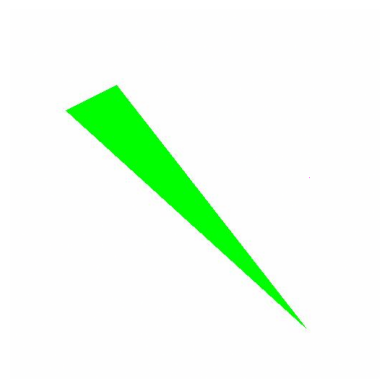

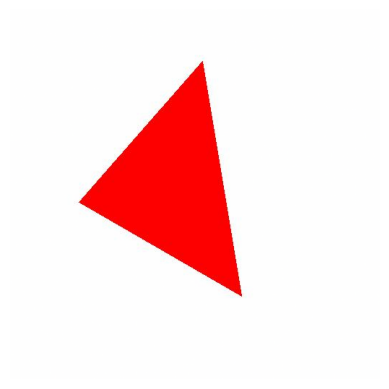

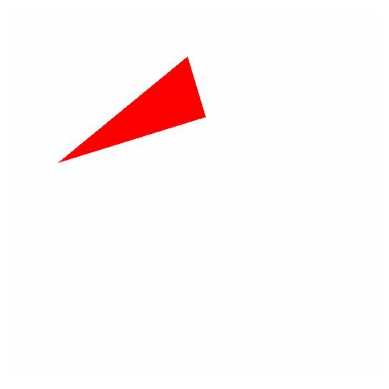

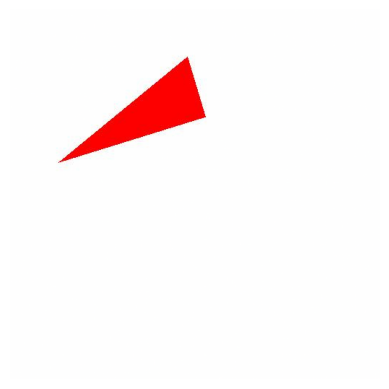

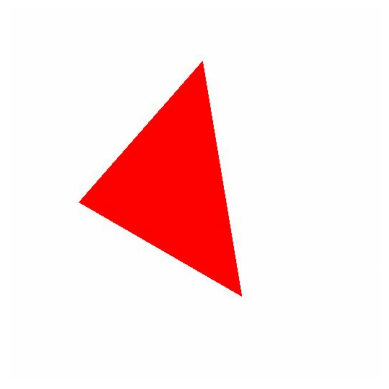

In [17]:
def add_random_noise(image):
    noise = np.random.normal(0,0.2, image.shape)
    return image + noise

datagenerator = ImageDataGenerator(preprocessing_function=add_random_noise)

for i, image in enumerate(datagenerator.flow(images, batch_size=1)):
    plt.figure(i)
    plt.imshow(image[0].astype('uint8'))
    plt.axis('off')
    plt.show()
    if i >= 4:  
        break




<details>
    <summary>Click here for Solution</summary>

```python

 

# Define a custom augmentation function to add random noise  

def add_random_noise(image):  

    noise = np.random.normal(0, 0.1, image.shape)  

    return image + noise  

 

# Create an instance of ImageDataGenerator with custom augmentation  

datagen = ImageDataGenerator(preprocessing_function=add_random_noise)  

 

# Generate and visualize augmented images  

i = 0  

for batch in datagen.flow(training_images, batch_size=1):  

    plt.figure(i)  

    imgplot = plt.imshow(array_to_img(batch[0]))  

    plt.title(f'Noisy Image {i + 1}')  

    i += 1  

    if i % 4 == 0:  

        break  

plt.show()  

 ```   

</details>


## **Conclusion**
Congratulations! You have successfully implemented and experimented with various data augmentation techniques using Keras. This lab exercise demonstrated how to use Keras to enhance your datasets through augmentation and normalization techniques. 


## Authors


Skillup 


Copyright © IBM Corporation. All rights reserved.
